# The guarded volatility-regime momentum model

This is the volatility-regime momentum model with an extra layer of defence. It quotes exactly the
same displayed probability (momentum, calibrated per volatility regime), but on top it charges an
**information margin**: whenever a richer hidden estimate of the up-probability disagrees with what we
display, we widen the spread just enough that a bettor who knew that hidden estimate could not profit.

**The idea in one line.** Price the direction as before, and add a small, targeted margin exactly
when the market is more predictable than our displayed curve admits, so informed bettors are priced
out while ordinary flow barely notices.

The companion notebook (`volatility_regime_momentum`) explains the displayed direction in full; here
we recap it quickly and focus on the guard. As before, all plumbing lives in `helper.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import helper

parameters = helper.MarketParameters()
features = helper.build_features(helper.load_prices(), parameters)
print(f"{features.number_of_seconds:,} seconds (~{features.number_of_seconds/86_400:.0f} days), "
      f"horizon {parameters.horizon_seconds}s, vig {parameters.house_margin:.1%}")

16,473,672 seconds (~191 days), horizon 30s, vig 12.5%


## Design choices at a glance

- **Keep the displayed direction unchanged** (volatility-regime momentum). It already prices the
  public momentum-by-volatility signal well.
- **Add an information margin from a hidden logistic estimate.** The displayed curve still leaves a
  small edge to a bettor who models the up-probability more richly. We estimate that richer
  probability with a walk-forward logistic on many features and charge a margin that makes such a
  bettor break even at best. In our internal study this drove the informed 'predictive' attacker's
  traded volume to essentially **zero** (it can no longer find a positive expected-value bet) and kept
  the residual regime-aware edge the lowest of any model we tried (about **+1%**).
- **The cost is competitiveness.** Charging extra margin means slightly worse odds in the moments the
  guard fires, so the model quotes a touch wider than the plain one. That is the deliberate trade: a
  little less volume for materially less informed leakage. Use this variant when arbitrage protection
  matters more than maximum volume.

## Part 1 - The displayed direction (recap)

The displayed probability is the volatility-regime momentum model: momentum calibrated per volatility
regime, monotone and shrunk, recalibrated on a rolling 90-day window every week. It is built in full
in the companion notebook; here we just build it and note it becomes live ~90 days in.

In [2]:
display_probability, first_evaluation_second = helper.build_volatility_regime_display(features, parameters)
print(f"model live from ~{first_evaluation_second/86_400:.0f} days in; displayed P(up) range "
      f"[{display_probability[first_evaluation_second:].min():.3f}, "
      f"{display_probability[first_evaluation_second:].max():.3f}]")

model live from ~90 days in; displayed P(up) range [0.386, 0.601]


## Part 2 - The hidden estimate

The guard needs a *better* estimate of the up-probability than the displayed curve. We fit a logistic
regression, walk-forward (trained only on past data, refit regularly), on a broad feature set:
momentum at several horizons, its magnitude, the annualized volatility, where the price sits in its
recent range, path efficiency, and acceleration. We never display this estimate; it is only used to
size the margin. The plot shows it is more confident (more spread) than the displayed curve.

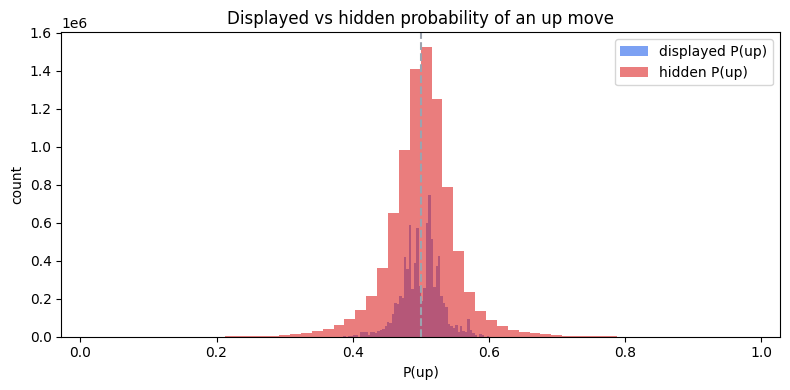

In [3]:
hidden_probability = helper.build_walk_forward_logistic_probability(features, parameters)

live = slice(first_evaluation_second, None)
plt.figure(figsize=(8, 4))
plt.hist(display_probability[live], bins=60, alpha=0.6, color="#2563eb", label="displayed P(up)")
plt.hist(hidden_probability[live], bins=60, alpha=0.6, color="#dc2626", label="hidden P(up)")
plt.axvline(0.5, ls="--", color="#9ca3af")
plt.title("Displayed vs hidden probability of an up move")
plt.xlabel("P(up)"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

## Part 3 - The information margin

For a displayed probability `q` and a hidden estimate `p`, on a balanced book the up odds are
`(1 - margin) / q`. A bettor whose true probability is `p` breaks even on the up side at
`margin = 1 - q / p`, and on the down side at `margin = 1 - (1 - q) / (1 - p)`. We charge the larger
of the two (and never negative), add a small buffer, and subtract the vig we already take. So the
extra margin is **zero when the hidden estimate agrees with what we display**, and rises only where
they disagree. The plot shows it kicking in at the confident extremes.

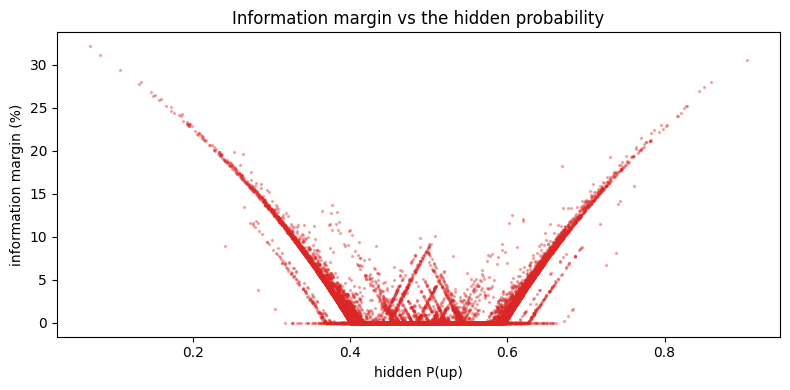

information margin: active 7.6% of the time, mean 0.357%, 95th pct 1.767%


In [4]:
information_margin = helper.information_margin_over_display(hidden_probability, display_probability, parameters)

sample = slice(first_evaluation_second, first_evaluation_second + 3_000_000, 25)
plt.figure(figsize=(8, 4))
plt.scatter(hidden_probability[sample], information_margin[sample] * 100, s=2, alpha=0.3, color="#dc2626")
plt.title("Information margin vs the hidden probability")
plt.xlabel("hidden P(up)"); plt.ylabel("information margin (%)")
plt.tight_layout(); plt.show()

fraction_active = (information_margin[live] > 1e-6).mean()
print(f"information margin: active {fraction_active:.1%} of the time, "
      f"mean {information_margin[live].mean():.3%}, 95th pct {np.percentile(information_margin[live], 95):.3%}")

## Part 4 - Total margin and pricing

The margin charged each second is the base vig plus the information margin (capped). Most of the time
it equals the vig; it widens only when the guard fires. Pricing is otherwise identical: the same
`quote_odds`, so on a quiet second a displayed 0.50 still gives ~1.75 each side, but on a second the
guard flags, both sides are shortened.

In [5]:
total_margin = np.clip(parameters.house_margin + information_margin, 0.0, parameters.maximum_total_margin)

guarded_second = first_evaluation_second + int(np.argmax(information_margin[first_evaluation_second:first_evaluation_second + 3_000_000]))
for label, t in [("typical second", first_evaluation_second + 10_000), ("guard firing", guarded_second)]:
    odds = helper.quote_odds(display_probability[t], total_margin[t], 0.0, parameters)
    print(f"{label:14s}: displayed P(up)={display_probability[t]:.3f}, margin={total_margin[t]:.3%} "
          f"-> odds up {odds[0]:.3f} / down {odds[1]:.3f}")

typical second: displayed P(up)=0.512, margin=12.500% -> odds up 1.709 / down 1.793
guard firing  : displayed P(up)=0.529, margin=48.015% -> odds up 0.983 / down 1.104


## Backtest with random (uninformed) flow

As before, we replay a balanced noise pool over out-of-sample windows and check the house edge is
steady and the book controlled. The guard lifts the average margin slightly, so the house edge sits a
touch above the base vig.

noise pool over 6 windows: house edge mean +13.344%, std 0.154%
  aggregate house edge +13.344%, max |net delta| $477 (cap $20,000)


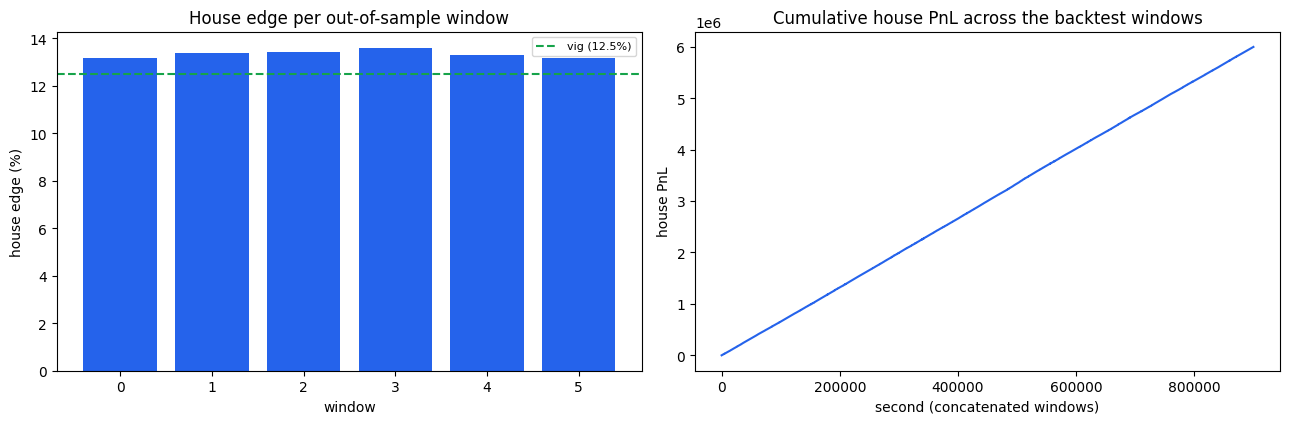

In [6]:
window_length = 150_000

def run_windows(make_flow, number_of_windows, seed_base=100):
    rows = []
    for w in range(number_of_windows):
        start = first_evaluation_second + w * window_length
        if start + window_length + parameters.horizon_seconds >= features.number_of_seconds:
            break
        rows.append(helper.simulate(display_probability, total_margin, features, make_flow(),
                                    start, window_length, parameters, seed=seed_base + w))
    return rows

noise_runs = run_windows(lambda: {"pool": helper.noise_pool()}, number_of_windows=6)
edges = np.array([r.house_edge for r in noise_runs])
total_pnl = sum(r.house_pnl for r in noise_runs); total_volume = sum(r.total_volume for r in noise_runs)
print(f"noise pool over {len(noise_runs)} windows: house edge mean {edges.mean():+.3%}, std {edges.std():.3%}")
print(f"  aggregate house edge {total_pnl/total_volume:+.3%}, "
      f"max |net delta| ${max(r.max_absolute_net_delta for r in noise_runs):,.0f} (cap ${parameters.maximum_net_delta:,.0f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(len(edges)), edges * 100, color="#2563eb")
axes[0].axhline(parameters.house_margin * 100, ls="--", color="#16a34a", label=f"vig ({parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window"); axes[0].set_xlabel("window"); axes[0].set_ylabel("house edge (%)")
axes[0].legend(fontsize=8)
running, offset = [], 0.0
for r in noise_runs:
    running.append(r.pnl_series + offset); offset += r.house_pnl
axes[1].plot(np.concatenate(running), color="#2563eb")
axes[1].set_title("Cumulative house PnL across the backtest windows")
axes[1].set_xlabel("second (concatenated windows)"); axes[1].set_ylabel("house PnL")
plt.tight_layout(); plt.show()

In [7]:
for name, factory in [("trend-following", lambda: {"bettor": helper.momentum_follower(features)}),
                      ("mean-reversion", lambda: {"bettor": helper.mean_reversion_fader(features)})]:
    runs = run_windows(factory, number_of_windows=4, seed_base=300)
    pnl = sum(r.per_bettor["bettor"].pnl for r in runs); stake = sum(r.per_bettor["bettor"].stake for r in runs)
    print(f"{name:16s} bettor edge = {pnl/stake:+.3%}  (house keeps {-pnl/stake:+.3%})")

trend-following  bettor edge = -9.043%  (house keeps +9.043%)


mean-reversion   bettor edge = -19.569%  (house keeps +19.569%)


## Smart flow: why it should not be a problem, and where it can hurt

**The predictive attacker is priced out by design.** An informed bettor who models the up-probability
with the same kind of logistic we use is exactly what the information margin defends against. Below,
such a bettor placed inside a noise pool finds almost no positive-expected-value bet, so its traded
volume collapses to near zero.

In [8]:
predictive_runs = run_windows(lambda: {"pool": helper.noise_pool(),
                                       "attacker": helper.expected_value_bettor(hidden_probability)},
                              number_of_windows=3, seed_base=400)
attacker_stake = sum(r.per_bettor["attacker"].stake for r in predictive_runs)
pool_stake = sum(r.per_bettor["pool"].stake for r in predictive_runs)
print(f"predictive attacker: volume share {attacker_stake/(attacker_stake+pool_stake):.2%} "
      f"(it barely finds a bet worth taking)")

predictive attacker: volume share 0.00% (it barely finds a bet worth taking)


**The residual threat is the regime-aware attacker**, using a momentum-by-volatility table with the
full un-shrunk edge. As with the plain model, its edge is small and capacity-limited: as it grows it
moves the book against itself.

               volume share  attacker edge
attacker size                             
0.5                     4.0           3.10
1.0                     7.0           2.94
3.0                    15.9           1.92
6.0                    26.6           1.01
10.0                   38.1           0.21
20.0                   58.1           0.34


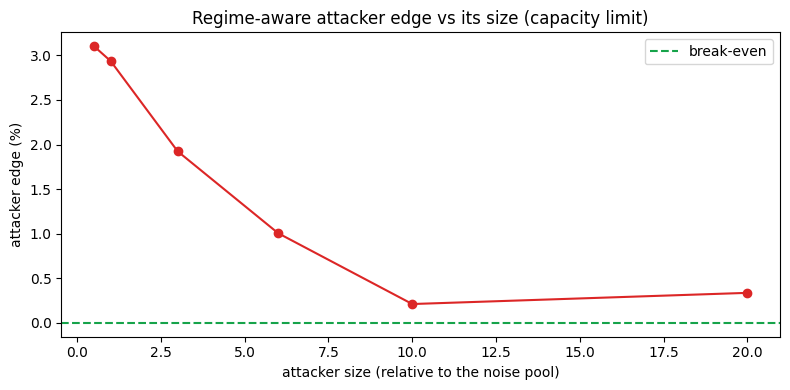

In [9]:
regime_signal = helper.regime_conditional_probability(features, parameters)
rows = []
for size in [0.5, 1, 3, 6, 10, 20]:
    attacker_pnl = attacker_stake = pool_volume = 0.0
    for w in range(3):
        start = first_evaluation_second + w * window_length
        result = helper.simulate(display_probability, total_margin, features,
                                 {"pool": helper.noise_pool(), "attacker": helper.regime_aware_bettor(regime_signal, size=size)},
                                 start, window_length, parameters, seed=500 + w)
        attacker_pnl += result.per_bettor["attacker"].pnl
        attacker_stake += result.per_bettor["attacker"].stake
        pool_volume += result.per_bettor["pool"].stake
    rows.append({"attacker size": size, "volume share": attacker_stake / (attacker_stake + pool_volume),
                 "attacker edge": attacker_pnl / attacker_stake if attacker_stake else 0.0})
capacity = pd.DataFrame(rows).set_index("attacker size")
print(capacity.assign(**{"volume share": (capacity["volume share"] * 100).round(1),
                         "attacker edge": (capacity["attacker edge"] * 100).round(2)}).to_string())

plt.figure(figsize=(8, 4))
plt.plot(capacity.index, capacity["attacker edge"] * 100, "o-", color="#dc2626")
plt.axhline(0, ls="--", color="#16a34a", label="break-even")
plt.title("Regime-aware attacker edge vs its size (capacity limit)")
plt.xlabel("attacker size (relative to the noise pool)"); plt.ylabel("attacker edge (%)")
plt.legend(); plt.tight_layout(); plt.show()

In [10]:
# A latency attacker on the faster Binance feed that leads the settlement oracle.
fast_feed = helper.load_fast_feed(expected_length=features.number_of_seconds)
runs = run_windows(lambda: {"pool": helper.noise_pool(),
                            "attacker": helper.lead_lag_bettor(features, fast_feed.log_price)},
                   number_of_windows=3, seed_base=700)
pnl = sum(r.per_bettor["attacker"].pnl for r in runs); stake = sum(r.per_bettor["attacker"].stake for r in runs)
print(f"latency (lead-lag) attacker edge at the {parameters.horizon_seconds}s horizon = {pnl/stake:+.3%}")

latency (lead-lag) attacker edge at the 30s horizon = -16.974%


**Latency is not a threat at this 30-second horizon.** The latency (lead-lag) attacker above, on a
feed one second ahead of the oracle, still loses heavily: a one-second lead over a 30-second contract
washes out before settlement, nowhere near enough to overcome our margin.

**Where smart flow can still hurt.**
- **Finer structure than three regimes.** The regime-aware attacker keeps a small positive edge on a
  tiny share of volume; it comes from volatility structure finer than three terciles. It is
  capacity-limited (above), and the guard already trims it below the plain model.
- **Regime shifts.** If the volatility/momentum relationship or the hidden signal changes faster than
  the rolling windows adapt.
- **Genuine private information** (news, unseen order flow). Unpriceable, but bounded by the net-delta cap.

## Model card

- **Prices:** the volatility-regime momentum direction (unchanged), plus an information margin sized
  from a walk-forward logistic estimate so a bettor who knows that estimate cannot profit.
- **Charges:** the vig plus the information margin, with inventory skew and a hard net-delta cap.
- **Strengths:** prices out the informed 'predictive' attacker (its volume goes to ~0), keeps the
  lowest residual regime-aware edge of any model, and holds a slightly higher house edge on uninformed
  flow.
- **Cost:** quotes a touch wider when the guard fires, so slightly less competitive than the plain
  model; choose it when arbitrage protection matters more than maximum volume.
- **Residual risks:** structure finer than three regimes, regime shifts, and private information; all
  small and bounded by the book controls.